# 02 - Tiền xử lý và phân tích dữ liệu đánh giá FPTShop Laptop
Notebook này tập trung làm sạch dữ liệu và phân tích mô tả, không sử dụng Machine Learning.

In [4]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
os.makedirs("outputs", exist_ok=True)

raw_path = "data/fptshop_laptop_raw.csv"
df = pd.read_csv(raw_path)

required_columns = [
    "review_id",
    "item_id",
    "user_id",
    "rating_star",
    "comment",
    "created_at",
    "like_count",
    "source"
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Thiếu cột bắt buộc trong dữ liệu thô: {missing_columns}")

print(f"Số dòng dữ liệu thô: {len(df)}")
display(df.head())

Số dòng dữ liệu thô: 9089


,review_id,shop_id,item_id,product_name,brand,price,final_price,rating_count_total,user_id,rating_star,...,image_review,created_at,like_count,product_items,reply_content,reply_created_at,reply_user_id,reply_is_admin,reply_like_count,source
0,Anh KhoiPD DX_201234,FPTShop,59564510814,Colorful Rimbook L1 i5- 13420H/A10205500050,Samsung,16990000.0,14990000.0,1,Anh KhoiPD DX,4.0,...,NaN,2026-04-05T07:54:54.114000+00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,FPTShop
1,Bình Nguyễn_196901,FPTShop,108185810205,Asus Zenbook 14 UX3405CA-ST629W Ultra 7-255H,Samsung,38690000.0,34090000.0,1,Bình Nguyễn,NaN,...,NaN,2026-03-28T01:12:58.994000+00:00,0,NaN,"Chào anh Bình Dạ, sản phẩm không có màn hình c...",2026-03-28T01:17:57+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop
2,Bình_210331,FPTShop,320017710671,MacBook Air 15 M5 2026 10CPU/10GPU/24GB/1TB,Samsung,45990000.0,45990000.0,1,Bình,NaN,...,NaN,2026-04-20T14:21:29.756000+00:00,1,NaN,"Chào anh Bình Dạ, cục sạc đi kèm là 35W ạ. Hiệ...",2026-04-20T14:25:41+00:00,Nguyễn Phương Thanh,True,0.0,FPTShop
3,Thanh_205235,FPTShop,431825326108,MacBook Pro 14 M5 Pro 2026 15CPU/16GPU/24GB/1TB,Samsung,59990000.0,59990000.0,1,Thanh,NaN,...,NaN,2026-04-12T08:04:37.157000+00:00,0,NaN,"Chào anh Thanh, Dạ mẫu này là mẫu M5 Pro thườn...",2026-04-12T08:07:58+00:00,Đông Chí Linh,True,0.0,FPTShop
4,A Dũng_205578,FPTShop,741367556191,MacBook Neo 13 inch 8GB/256GB,Samsung,16490000.0,16490000.0,29,A Dũng,NaN,...,NaN,2026-04-12T14:04:10.428000+00:00,0,NaN,"Chào anh Dũng, Dạ hiện em kiểm tra thì máy này...",2026-04-12T14:18:43+00:00,Đông Chí Linh,True,0.0,FPTShop


In [7]:
def normalize_text(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Chuẩn hóa các cột text mới từ bước crawl nếu có
for col in ["comment", "review_title", "reply_content", "product_name", "brand", "product_items"]:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

df["comment_clean"] = df["comment"].apply(normalize_text)
if "reply_content" in df.columns:
    df["reply_content_clean"] = df["reply_content"].apply(normalize_text)

# Chỉ giữ review có nội dung hợp lệ
df = df[df["comment_clean"].str.len() > 0].copy()
df = df.drop_duplicates(subset=["review_id", "comment_clean"]).reset_index(drop=True)

df["rating_star"] = pd.to_numeric(df["rating_star"], errors="coerce")
df = df[df["rating_star"].between(1, 5, inclusive="both")].copy()
df["review_len"] = df["comment_clean"].str.len()

# Chuẩn hóa thời gian
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
if "reply_created_at" in df.columns:
    df["reply_created_at"] = pd.to_datetime(df["reply_created_at"], errors="coerce")

# Cờ có phản hồi từ shop/quản trị (nếu dữ liệu có cột này)
if "reply_content" in df.columns:
    df["has_reply"] = df["reply_content"].str.strip().str.len() > 0
else:
    df["has_reply"] = False

print(f"Số dòng sau làm sạch: {len(df)}")
print(f"Tỷ lệ review có phản hồi: {df['has_reply'].mean():.2%}")
display(df.head())

Số dòng sau làm sạch: 3780
Tỷ lệ review có phản hồi: 9.07%


,review_id,shop_id,item_id,product_name,brand,price,final_price,rating_count_total,user_id,rating_star,...,reply_content,reply_created_at,reply_user_id,reply_is_admin,reply_like_count,source,comment_clean,reply_content_clean,review_len,has_reply
0,Anh KhoiPD DX_201234,FPTShop,59564510814,Colorful Rimbook L1 i5- 13420H/A10205500050,Samsung,16990000.0,14990000.0,1,Anh KhoiPD DX,4.0,...,,NaT,NaN,NaN,NaN,FPTShop,máy dùng tốt,,12,False
6,Võ Diệp Khai_204189,FPTShop,741367556191,MacBook Neo 13 inch 8GB/256GB,Samsung,16490000.0,16490000.0,29,Võ Diệp Khai,5.0,...,,NaT,NaN,NaN,NaN,FPTShop,nhân viên hỗ trợ tue vấn trả góp nhanh chóng,,44,False
21,Chị Nga Xinh Đẹp book hàng_188693,FPTShop,741367556191,MacBook Neo 13 inch 8GB/256GB,Samsung,16490000.0,16490000.0,29,Chị Nga Xinh Đẹp book hàng,5.0,...,,NaT,NaN,NaN,NaN,FPTShop,giá mịm quá ạ,,13,False
22,DƯ_187944,FPTShop,741367556191,MacBook Neo 13 inch 8GB/256GB,Samsung,16490000.0,16490000.0,29,DƯ,5.0,...,,NaT,NaN,NaN,NaN,FPTShop,màu năm nay đẹp phết màu hồng nhìn mê quá mê l...,,57,False
23,Chị Dung_187943,FPTShop,741367556191,MacBook Neo 13 inch 8GB/256GB,Samsung,16490000.0,16490000.0,29,Chị Dung,4.0,...,,NaT,NaN,NaN,NaN,FPTShop,chi phí này thì quá ngon để tậu ngay 1 chiếc m...,,78,False


In [8]:
summary = pd.DataFrame({
    "metric": [
        "count_reviews",
        "min_rating",
        "max_rating",
        "avg_rating",
        "median_rating",
        "avg_review_len",
        "min_review_len",
        "max_review_len"
    ],
    "value": [
        len(df),
        df["rating_star"].min(),
        df["rating_star"].max(),
        round(df["rating_star"].mean(), 4),
        df["rating_star"].median(),
        round(df["review_len"].mean(), 2),
        df["review_len"].min(),
        df["review_len"].max()
    ]
})

display(summary)
summary.to_csv("outputs/eda_summary.csv", index=False, encoding="utf-8-sig")

,metric,value
0,count_reviews,3780.000
1,min_rating,1.000
2,max_rating,5.000
3,avg_rating,4.737
4,median_rating,5.000
5,avg_review_len,108.650
6,min_review_len,2.000
7,max_review_len,424.000


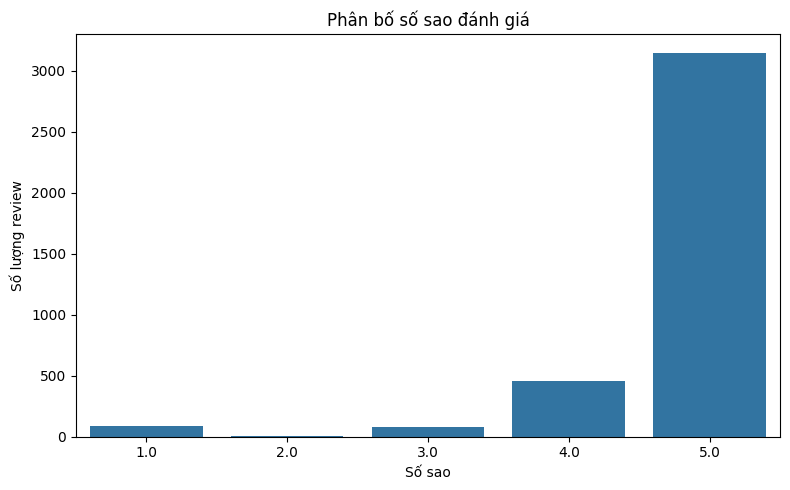

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rating_star", color="#1f77b4")
plt.title("Phân bố số sao đánh giá")
plt.xlabel("Số sao")
plt.ylabel("Số lượng review")
plt.tight_layout()
plt.savefig("outputs/chart_rating_distribution.png", dpi=150)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_4620\2219752114.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_time["month"] = df_time["created_at"].dt.to_period("M").astype(str)


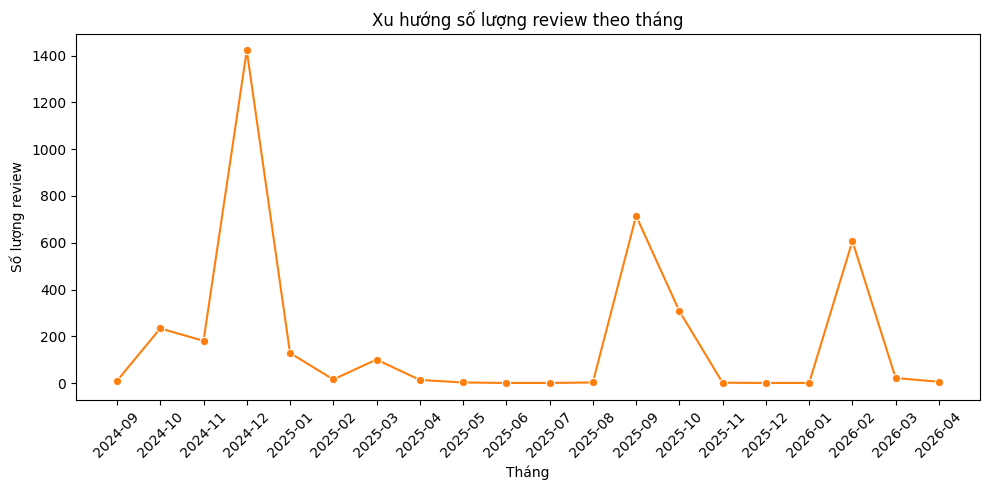

In [10]:
if df["created_at"].notna().any():
    df_time = df.dropna(subset=["created_at"]).copy()
    df_time["month"] = df_time["created_at"].dt.to_period("M").astype(str)
    monthly_count = df_time.groupby("month").size().reset_index(name="review_count")

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_count, x="month", y="review_count", marker="o", color="#ff7f0e")
    plt.title("Xu hướng số lượng review theo tháng")
    plt.xlabel("Tháng")
    plt.ylabel("Số lượng review")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("outputs/chart_monthly_trend.png", dpi=150)
    plt.show()

    monthly_count.to_csv("outputs/table_monthly_trend.csv", index=False, encoding="utf-8-sig")
else:
    print("Không đủ dữ liệu thời gian để vẽ xu hướng theo tháng.")

In [11]:
stopwords_vi = {
    "và", "là", "của", "cho", "rất", "nhưng", "được", "mình", "shop", "sản", "phẩm",
    "này", "khi", "thì", "với", "có", "không", "đã", "trong", "hơi", "vẫn"
}

tokens = []
for text in df["comment_clean"]:
    words = [w for w in text.split() if len(w) >= 3 and w not in stopwords_vi]
    tokens.extend(words)

top_terms = pd.DataFrame(Counter(tokens).most_common(30), columns=["term", "frequency"])
display(top_terms.head(15))
top_terms.to_csv("outputs/table_top_terms.csv", index=False, encoding="utf-8-sig")

,term,frequency
0,máy,2191
1,hình,1097
2,tốt,1075
3,dùng,1007
4,việc,923
5,nhanh,837
6,làm,827
7,màn,764
8,năng,683
9,hiệu,617


In [12]:
rating_table = df.groupby("rating_star").size().reset_index(name="review_count").sort_values("rating_star")
display(rating_table)
rating_table.to_csv("outputs/table_rating_distribution.csv", index=False, encoding="utf-8-sig")

clean_path = "data/cleaned_reviews.csv"
df.to_csv(clean_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu dữ liệu sạch vào: {clean_path}")

,rating_star,review_count
0,1.0,86
1,2.0,10
2,3.0,83
3,4.0,454
4,5.0,3147


Đã lưu dữ liệu sạch vào: data/cleaned_reviews.csv
